# Priority Classifier

### Pipeline
1. Carica `dataset_clean.csv` e split temporale
2. Calcola embedding **intfloat/multilingual-e5-base** su CPU (con caching su disco)
3. Feature engineering OHE (priorità iniziale cliente)
4. Costruzione feature matrix (embedding + OHE)
5. Definizione pesi classi (`molt_p1=0.25`, `molt_p2=2.0`, `C=1.0`)
6. Training **LinearSVC** — metrica finale: **Macro F1**
7. Analisi pesi feature
8. Confusion matrix + analisi errori
9. Salvataggio in `modelli/priority_v2/`
10. Analisi confidenza sugli errori P1↔P2

---
## STEP 1 — Caricamento dataset e split temporale

In [1]:
import pandas as pd
import numpy as np
import warnings
import time
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# Il kernel VS Code parte dalla cartella notebooks/, non dalla root del progetto.
# os.path.abspath('') restituisce la directory corrente del kernel,
# quindi .parent risale di un livello e otteniamo la root di TicketClassifier/.
BASE_DIR = Path(os.path.abspath('')).parent

DATA_DIR = BASE_DIR / 'data'
EMB_DIR  = BASE_DIR / 'embeddings'
MOD_DIR  = BASE_DIR / 'modelli'

# Lo split e' temporale (non random) per simulare un vero scenario produttivo:
# il modello viene addestrato su dati storici e valutato su dati futuri.
# Uno split random sovrastimerebbe le performance perche' ticket simili
# (stesso cliente, stesso tipo di problema) finirebbero sia in train che in test.
SOGLIA_SPLIT = '2025-11-21'

df = pd.read_csv(DATA_DIR / 'dataset_clean.csv', parse_dates=['data_creazione'])

df_train = df[df['data_creazione'] < SOGLIA_SPLIT].copy()
df_test  = df[df['data_creazione'] >= SOGLIA_SPLIT].copy()

print(f"Dataset totale  : {len(df):,} ticket")
print(f"Train (<{SOGLIA_SPLIT})  : {len(df_train):,} ({len(df_train)/len(df):.2%})")
print(f"Test  (>={SOGLIA_SPLIT}) : {len(df_test):,} ({len(df_test)/len(df):.2%})")
print(f"\nDistribuzione priorita' — train:")
print(df_train['priorita_finale'].value_counts().sort_index())
print(f"\nDistribuzione priorita' — test:")
print(df_test['priorita_finale'].value_counts().sort_index())

Dataset totale  : 61,156 ticket
Train (<2025-11-21)  : 48,813 (79.82%)
Test  (>=2025-11-21) : 12,343 (20.18%)

Distribuzione priorita' — train:
priorita_finale
P1     6799
P2    14322
P3    26409
P4     1283
Name: count, dtype: int64

Distribuzione priorita' — test:
priorita_finale
P1    1582
P2    3415
P3    7087
P4     259
Name: count, dtype: int64


---
## STEP 2 — Calcolo embedding E5 su CPU (con caching su disco)

Il testo viene prefissato con `query: ` come richiesto dal modello **intfloat/multilingual-e5-base**.  
Se i file `.npy` esistono gia' nella cartella `embeddings/` vengono caricati direttamente,
altrimenti vengono calcolati su CPU e salvati per le run successive.

In [2]:
from sentence_transformers import SentenceTransformer

MODEL_NAME     = 'intfloat/multilingual-e5-base'
EMB_TRAIN_PATH = EMB_DIR / 'e5_train.npy'
EMB_TEST_PATH  = EMB_DIR / 'e5_test.npy'

# Carica embedding se già esistono, altrimenti li calcola e li salva
def get_embeddings(df, path):
    if path.exists():
        print(f"Carico {path.name}...")
        return np.load(path)
    
    # Il calcolo su CPU richiede diversi minuti — viene fatto solo una volta
    print(f"Calcolo embeddings su CPU (questo potrebbe richiedere diversi minuti)...")
    model = SentenceTransformer(MODEL_NAME, device='cpu')
    emb = model.encode(
        ("query: " + df['testo_input'].astype(str)).tolist(),
        batch_size=64,              # batch più grandi = più veloce ma più RAM
        normalize_embeddings=True,  # norma L2 = 1.0 → dot product equivale a cosine similarity
        show_progress_bar=True,
    )
    np.save(path, emb)
    return emb

X_emb_train = get_embeddings(df_train, EMB_TRAIN_PATH)
X_emb_test  = get_embeddings(df_test,  EMB_TEST_PATH)

print(f"Train: {X_emb_train.shape} | Test: {X_emb_test.shape}")

Carico e5_train.npy...
Carico e5_test.npy...
Train: (48813, 768) | Test: (12343, 768)


---
## STEP 3 OneHotEncoding

In [3]:
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder

CAT_COLS  = ['priorita_iniziale_cliente']

# Il fit viene fatto solo su train per evitare data leakage:
# il modello non deve "vedere" quali categorie esistono nel test set.
# handle_unknown='ignore': se nel test compare una categoria non vista in train,
# produce un vettore di zeri invece di dare errore
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder.fit(df_train[CAT_COLS])

X_cat_train = encoder.transform(df_train[CAT_COLS])
X_cat_test  = encoder.transform(df_test[CAT_COLS])

print(f"Feature categoriche (OHE): {X_cat_train.shape[1]} colonne")
print(f"  Categorie: {encoder.categories_[0].tolist()}")

Feature categoriche (OHE): 4 colonne
  Categorie: ['P1', 'P2', 'P3', 'P4']


---
## STEP 4 — Costruzione feature matrix finale

Combiniamo le due componenti in un'unica matrice sparsa:

In [4]:
# Converti embedding densi in sparse per hstack
X_emb_train_sp = sp.csr_matrix(X_emb_train)
X_emb_test_sp  = sp.csr_matrix(X_emb_test)

# hstack: unisce colonna per colonna i due blocchi di feature
X_train = sp.hstack([X_emb_train_sp, X_cat_train])
X_test  = sp.hstack([X_emb_test_sp,  X_cat_test])

y_train = df_train['priorita_finale'].values
y_test  = df_test['priorita_finale'].values

print(f"Feature matrix train: {X_train.shape}")
print(f"Feature matrix test:  {X_test.shape}")
print(f"  └── embedding:   768 colonne")
print(f"  └── OHE categ.:  {X_cat_train.shape[1]} colonne")
print(f"  └── TOTALE:      {X_train.shape[1]} colonne")
print(f"\nClassi target: {np.unique(y_train)}")

Feature matrix train: (48813, 772)
Feature matrix test:  (12343, 772)
  └── embedding:   768 colonne
  └── OHE categ.:  4 colonne
  └── TOTALE:      772 colonne

Classi target: ['P1' 'P2' 'P3' 'P4']


---
## STEP 5 — Definizione pesi classi

Pesi scelti per bilanciare **precision P1** senza sacrificare il recall complessivo.  
La metrica di valutazione finale rimane **F1-score** (macro).

| Parametro | Valore | Effetto |
|---|---|---|
| `molt_p1 = 0.25` | 25% del peso balanced | Il modello è più selettivo nel predire P1 → precision P1 sale |
| `molt_p2 = 2.0`  | doppio del peso balanced | Penalizza P2 verso l'alto → riduce falsi positivi P1 (confusioni P2→P1) |
| `C = 1.0` | fisso | Ottimale su embedding L2-normalizzati |

In [5]:
from collections import Counter

MOLT_P1 = 0.25
MOLT_P2 = 2.0
C_OTTIMALE = 1.0

# Pesi balanced come baseline di riferimento
counts = Counter(y_train)
n_total = len(y_train)
balanced_weights = {c: n_total / (4 * counts[c]) for c in counts}

pesi_ottimali = {
    'P1': balanced_weights['P1'] * MOLT_P1,
    'P2': balanced_weights['P2'] * MOLT_P2,
    'P3': balanced_weights['P3'],
    'P4': balanced_weights['P4'],
}

print("Pesi applicati:")
print(f"  {'Classe':<6} {'Ottimali':>10}  {'Balanced (ref)':>16}")
print(f"  {'-'*36}")
for c in sorted(pesi_ottimali):
    print(f"  {c:<6} {pesi_ottimali[c]:>10.4f}  {balanced_weights[c]:>16.4f}")

Pesi applicati:
  Classe   Ottimali    Balanced (ref)
  ------------------------------------
  P1         0.4487            1.7949
  P2         1.7041            0.8521
  P3         0.4621            0.4621
  P4         9.5115            9.5115


---
## STEP 6 — Training finale con pesi ottimali (C=1)

In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import time

print(f"Training LinearSVC  C={C_OTTIMALE}  molt_p1={MOLT_P1}  molt_p2={MOLT_P2}...")
t0 = time.time()

clf = LinearSVC(
    class_weight=pesi_ottimali,
    max_iter=3000,
    C=C_OTTIMALE,
    random_state=42
)
clf.fit(X_train, y_train)
print(f"Training completato in {time.time()-t0:.1f}s")

y_pred = clf.predict(X_test)

macro_f1   = f1_score(y_test, y_pred, average='macro')
accuracy   = (y_pred == y_test).mean()
prec_p1_ts = precision_score(y_test, y_pred, labels=['P1'], average='micro', zero_division=0)
rec_p1_ts  = recall_score(y_test, y_pred, labels=['P1'], average='micro', zero_division=0)

print(f"\n{'='*60}")
print(f"RISULTATI — E5-base + LinearSVC (molt_p1={MOLT_P1}, molt_p2={MOLT_P2})")
print(f"{'='*60}")
print(f"Macro F1:     {macro_f1:.4f}")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision P1: {prec_p1_ts:.4f}  |  Recall P1: {rec_p1_ts:.4f}")
print()
print(classification_report(y_test, y_pred, digits=3))

Training LinearSVC  C=1.0  molt_p1=0.25  molt_p2=2.0...
Training completato in 46.1s

RISULTATI — E5-base + LinearSVC (molt_p1=0.25, molt_p2=2.0)
Macro F1:     0.8543
Accuracy:     0.8986
Precision P1: 0.7709  |  Recall P1: 0.7762

              precision    recall  f1-score   support

          P1      0.771     0.776     0.774      1582
          P2      0.802     0.925     0.859      3415
          P3      0.985     0.919     0.951      7087
          P4      0.964     0.734     0.833       259

    accuracy                          0.899     12343
   macro avg      0.881     0.839     0.854     12343
weighted avg      0.906     0.899     0.900     12343



---
## STEP 7 — Analisi pesi delle features

In [7]:
# Analisi importanza gruppi di feature (embedding vs categoriche vs urgenza)
# Stesso calcolo della v1 — confrontiamo i valori

n_emb  = 768
n_cat  = X_cat_train.shape[1]

print("=== Peso medio assoluto per gruppo di feature ===")
print(f"{'Classe':<8} {'Embedding':>12} {'Priorità_cli':>14}")
print("-" * 52)

for i, classe in enumerate(clf.classes_):
    coef = clf.coef_[i]
    peso_emb  = np.abs(coef[:n_emb]).mean()
    peso_cat  = np.abs(coef[n_emb:n_emb+n_cat]).mean()
    peso_bool = np.abs(coef[n_emb+n_cat:]).mean()
    print(f"{classe:<8} {peso_emb:>12.4f} {peso_cat:>14.4f}")

print()

=== Peso medio assoluto per gruppo di feature ===
Classe      Embedding   Priorità_cli
----------------------------------------------------
P1             0.5195         0.6838
P2             0.3987         0.7183
P3             0.1631         0.7238
P4             0.7525         0.9520



---
## STEP 8 — Confusion matrix e analisi errori

<Figure size 1400x500 with 0 Axes>

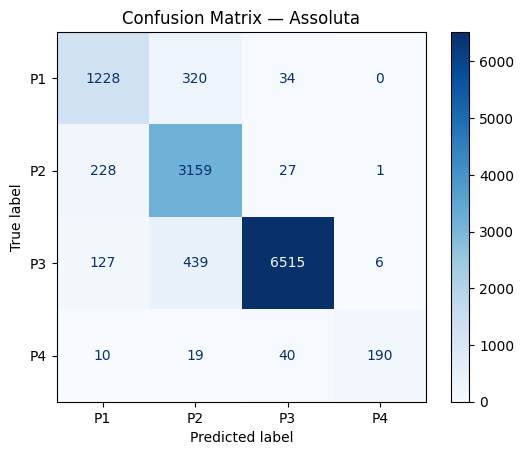


Errori totali: 1,251 su 12,343 (10.1%)

Top coppie di confusione:
reale  predetto
P3     P2          439
P1     P2          320
P2     P1          228
P3     P1          127
P4     P3           40
P1     P3           34
P2     P3           27
P4     P2           19


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


plt.figure(figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Blues'
)

plt.title('Confusion Matrix — Assoluta')
plt.show()

# Errori più frequenti
df_err = pd.DataFrame({'reale': y_test, 'predetto': y_pred})
errori = df_err[df_err['reale'] != df_err['predetto']]
print(f"\nErrori totali: {len(errori):,} su {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)")
print("\nTop coppie di confusione:")
print(
    errori.groupby(['reale', 'predetto']).size()
    .sort_values(ascending=False).head(8).to_string()
)

---
## STEP 9 — Salvataggio modello

In [9]:
import joblib
import json

SAVE_DIR = MOD_DIR / 'priority_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(clf,     SAVE_DIR / 'classificatore_svc.pkl')
joblib.dump(encoder, SAVE_DIR / 'ohe_encoder.pkl')

metadata = {
    'versione': 'v2',
    'modello_embedding': 'intfloat/multilingual-e5-base',
    'prefisso_e5': 'query: ',
    'classificatore': 'LinearSVC',
    'C': C_OTTIMALE,
    'molt_p1': MOLT_P1,
    'molt_p2': MOLT_P2,
    'pesi': {c: round(w, 6) for c, w in sorted(pesi_ottimali.items())},
    'feature': [
        'embedding_e5_768d',
        'priorita_iniziale_cliente_ohe',
    ],
    'classi': clf.classes_.tolist(),
    'split': 'temporale',
    'soglia_split': SOGLIA_SPLIT,
    'macro_f1_test':     round(float(f1_score(y_test, y_pred, average='macro')), 4),
    'accuracy_test':     round(float((y_pred == y_test).mean()), 4),
    'precision_p1_test': round(float(prec_p1_ts), 4),
    'recall_p1_test':    round(float(rec_p1_ts), 4),
    'n_train': int(len(y_train)),
    'n_test':  int(len(y_test)),
}

with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Modello salvato in: {SAVE_DIR}")
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modello salvato in: c:\Users\matteo.segatto\Desktop\TicketClassifier\modelli\priority_v2

{
  "versione": "v2",
  "modello_embedding": "intfloat/multilingual-e5-base",
  "prefisso_e5": "query: ",
  "classificatore": "LinearSVC",
  "C": 1.0,
  "molt_p1": 0.25,
  "molt_p2": 2.0,
  "pesi": {
    "P1": 0.448715,
    "P2": 1.704127,
    "P3": 0.462087,
    "P4": 9.511496
  },
  "feature": [
    "embedding_e5_768d",
    "priorita_iniziale_cliente_ohe"
  ],
  "classi": [
    "P1",
    "P2",
    "P3",
    "P4"
  ],
  "split": "temporale",
  "soglia_split": "2025-11-21",
  "macro_f1_test": 0.8543,
  "accuracy_test": 0.8986,
  "precision_p1_test": 0.7709,
  "recall_p1_test": 0.7762,
  "n_train": 48813,
  "n_test": 12343
}


---
## STEP 10 — Analisi confidenza sugli errori P1↔P2

`LinearSVC` produce **decision scores** (distanza dall'iperpiano), non probabilità.  
Applichiamo **softmax** ai decision scores: trasformazione monotona che schiaccia i valori in [0,1]
sommando a 1, senza alterare l'ordine → le predizioni rimangono **identiche al 100%** alla confusion matrix.

### Domande a cui risponde questa analisi
1. I **P1 classificati come P2** — con quanta sicurezza il modello ha sbagliato?
2. I **P2 classificati come P1** — stessa domanda nella direzione opposta?
3. Campione di 10 ticket per ciascun gruppo per revisione manuale.

In [10]:
from scipy.special import softmax

# clf è il classificatore ottimizzato (pesi selezionati da grid search CV su precision P1).
# Non si riallena nulla — si usano direttamente i suoi decision scores.
#
# decision_function → shape (n, 4): distanza con segno dall'iperpiano per ogni classe
# softmax           → trasformazione monotona che schiaccia i valori in [0,1] sommando a 1
#
# Proprietà chiave: argmax(softmax(x)) == argmax(x) sempre → PREDIZIONI IDENTICHE AL 100%

scores = clf.decision_function(X_test)   # shape (n_test, 4)
probs  = softmax(scores, axis=1)         # shape (n_test, 4) — pseudo-probabilità

# Verifica coerenza: deve essere 1.0000 per garanzia matematica
y_pred_soft = np.array([clf.classes_[i] for i in probs.argmax(axis=1)])
coerenza = (y_pred_soft == clf.predict(X_test)).mean()
print(f"Coerenza predizioni clf vs softmax: {coerenza:.4f}  (atteso: 1.0000)")

classes_cal  = clf.classes_
class_to_idx = {c: i for i, c in enumerate(classes_cal)}

print(f"\nErrori P1↔P2:")
n_p1p2 = ((y_test == 'P1') & (y_pred == 'P2')).sum()
n_p2p1 = ((y_test == 'P2') & (y_pred == 'P1')).sum()
print(f"  P1 → P2 : {n_p1p2}")
print(f"  P2 → P1 : {n_p2p1}")

Coerenza predizioni clf vs softmax: 1.0000  (atteso: 1.0000)

Errori P1↔P2:
  P1 → P2 : 320
  P2 → P1 : 228


In [11]:
# ── Costruzione DataFrame risultati ──
df_test_res = df_test.reset_index(drop=True).copy()
df_test_res['y_true'] = y_test
df_test_res['y_pred'] = y_pred

idx_p1 = class_to_idx['P1']
idx_p2 = class_to_idx['P2']

df_test_res['prob_P1']    = probs[:, idx_p1]
df_test_res['prob_P2']    = probs[:, idx_p2]
df_test_res['confidenza'] = probs.max(axis=1)   # prob della classe predetta

# ── Selezione dei due gruppi di errori ──
mask_p1_as_p2 = (df_test_res['y_true'] == 'P1') & (df_test_res['y_pred'] == 'P2')
mask_p2_as_p1 = (df_test_res['y_true'] == 'P2') & (df_test_res['y_pred'] == 'P1')

df_p1_as_p2 = df_test_res[mask_p1_as_p2].copy()
df_p2_as_p1 = df_test_res[mask_p2_as_p1].copy()

print(f"P1 classificati come P2 : {len(df_p1_as_p2):,}")
print(f"P2 classificati come P1 : {len(df_p2_as_p1):,}")

# ── Soglie di confidenza ──
for nome, df_err in [('P1 → P2', df_p1_as_p2), ('P2 → P1', df_p2_as_p1)]:
    conf = df_err['confidenza']
    print(f"\n[{nome}]  n={len(df_err)}")
    print(f"  Confidenza media   : {conf.mean():.3f}")
    print(f"  Confidenza mediana : {conf.median():.3f}")
    print(f"  > 70%  : {(conf > 0.70).sum():>4}  ({(conf > 0.70).mean()*100:.1f}%)")
    print(f"  > 80%  : {(conf > 0.80).sum():>4}  ({(conf > 0.80).mean()*100:.1f}%)")
    print(f"  > 90%  : {(conf > 0.90).sum():>4}  ({(conf > 0.90).mean()*100:.1f}%)")
    print(f"  > 95%  : {(conf > 0.95).sum():>4}  ({(conf > 0.95).mean()*100:.1f}%)")

P1 classificati come P2 : 320
P2 classificati come P1 : 228

[P1 → P2]  n=320
  Confidenza media   : 0.422
  Confidenza mediana : 0.395
  > 70%  :   11  (3.4%)
  > 80%  :    2  (0.6%)
  > 90%  :    0  (0.0%)
  > 95%  :    0  (0.0%)

[P2 → P1]  n=228
  Confidenza media   : 0.424
  Confidenza mediana : 0.405
  > 70%  :    0  (0.0%)
  > 80%  :    0  (0.0%)
  > 90%  :    0  (0.0%)
  > 95%  :    0  (0.0%)


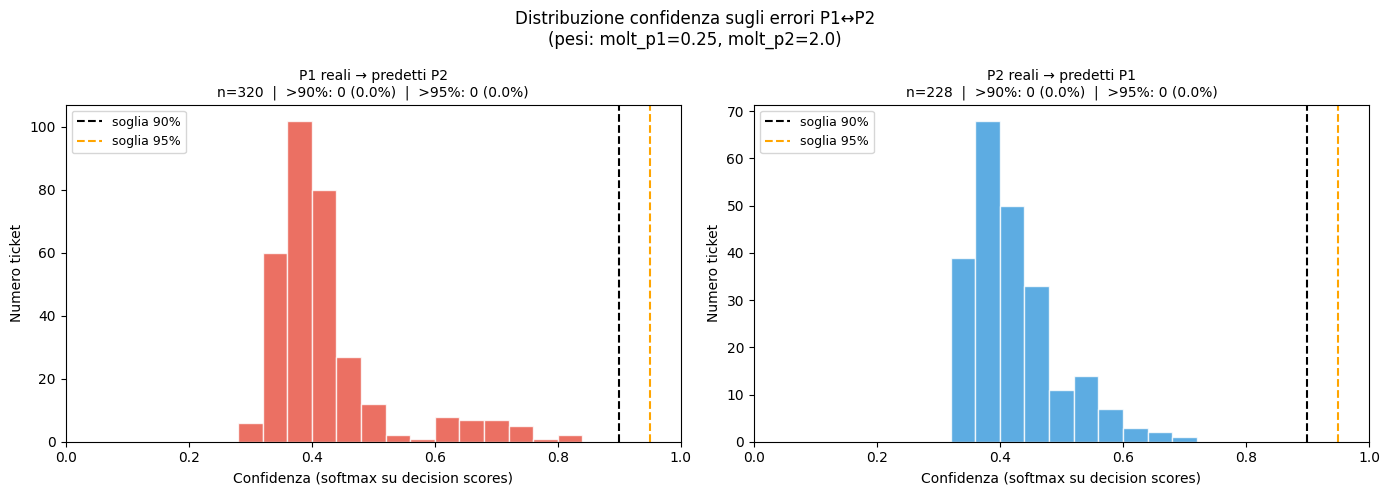

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 1, 26)

for ax, (nome, df_err, colore) in zip(axes, [
    ('P1 reali → predetti P2', df_p1_as_p2, '#e74c3c'),
    ('P2 reali → predetti P1', df_p2_as_p1, '#3498db'),
]):
    conf = df_err['confidenza']
    ax.hist(conf, bins=bins, color=colore, alpha=0.8, edgecolor='white')
    ax.axvline(0.90, color='black',  linestyle='--', linewidth=1.5, label='soglia 90%')
    ax.axvline(0.95, color='orange', linestyle='--', linewidth=1.5, label='soglia 95%')

    n90 = (conf > 0.90).sum()
    n95 = (conf > 0.95).sum()
    ax.set_title(
        f'{nome}\nn={len(df_err)}  |  >90%: {n90} ({n90/len(df_err)*100:.1f}%)  |  >95%: {n95} ({n95/len(df_err)*100:.1f}%)',
        fontsize=10
    )
    ax.set_xlabel('Confidenza (softmax su decision scores)')
    ax.set_ylabel('Numero ticket')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.suptitle(
    f'Distribuzione confidenza sugli errori P1↔P2\n'
    f'(pesi: molt_p1={MOLT_P1}, molt_p2={MOLT_P2})',
    fontsize=12
)
plt.tight_layout()
plt.show()

In [13]:
def mostra_campione(df_err, titolo, n=10, seed=42):
    campione = df_err.sample(min(n, len(df_err)), random_state=seed).reset_index(drop=True)
    print("=" * 55)
    print(f"  {titolo}  —  campione di {len(campione)} ticket")
    print("=" * 55)
    print(f"  {'Ticket':<20} {'Reale':<8} {'Predetto':<10} {'Confidenza'}")
    print(f"  {'─'*20} {'─'*7} {'─'*9} {'─'*10}")
    for _, row in campione.iterrows():
        print(f"  {str(row.get('case_number', 'N/A')):<20} {row['y_true']:<8} {row['y_pred']:<10} {row['confidenza']:.3f}")
    print()

# ── Campione 1: P1 reali classificati come P2 ──
mostra_campione(df_p1_as_p2, titolo="P1 → predetti P2  (falsi negativi P1)")

# ── Campione 2: P2 reali classificati come P1 ──
mostra_campione(df_p2_as_p1, titolo="P2 → predetti P1  (falsi positivi P1)")

  P1 → predetti P2  (falsi negativi P1)  —  campione di 10 ticket
  Ticket               Reale    Predetto   Confidenza
  ──────────────────── ─────── ───────── ──────────
  264472               P1       P2         0.544
  267504               P1       P2         0.425
  270221               P1       P2         0.359
  275535               P1       P2         0.405
  271962               P1       P2         0.394
  272029               P1       P2         0.355
  274989               P1       P2         0.736
  273313               P1       P2         0.678
  267092               P1       P2         0.383
  271493               P1       P2         0.357

  P2 → predetti P1  (falsi positivi P1)  —  campione di 10 ticket
  Ticket               Reale    Predetto   Confidenza
  ──────────────────── ─────── ───────── ──────────
  265620               P2       P1         0.415
  268055               P2       P1         0.389
  270161               P2       P1         0.424
  264072          

In [14]:
from scipy.special import softmax
import numpy as np

scores    = clf.decision_function(X_test)
probs_all = softmax(scores, axis=1)
conf_pred = probs_all.max(axis=1)

mask_corretti = (y_pred == y_test)
mask_errori   = ~mask_corretti

print("="*55)
print("  CONFIDENZA — CORRETTI vs ERRORI")
print("="*55)
print(f"\n  Corretti ({mask_corretti.sum()} ticket):")
print(f"    media:   {conf_pred[mask_corretti].mean():.3f}")
print(f"    mediana: {np.median(conf_pred[mask_corretti]):.3f}")
print(f"    > 70%:   {(conf_pred[mask_corretti]>0.70).mean():.1%}")
print(f"    > 80%:   {(conf_pred[mask_corretti]>0.80).mean():.1%}")
print(f"    > 90%:   {(conf_pred[mask_corretti]>0.90).mean():.1%}")

print(f"\n  Errori ({mask_errori.sum()} ticket):")
print(f"    media:   {conf_pred[mask_errori].mean():.3f}")
print(f"    mediana: {np.median(conf_pred[mask_errori]):.3f}")
print(f"    > 70%:   {(conf_pred[mask_errori]>0.70).mean():.1%}")
print(f"    > 80%:   {(conf_pred[mask_errori]>0.80).mean():.1%}")
print(f"    > 90%:   {(conf_pred[mask_errori]>0.90).mean():.1%}")

print("\n  Breakdown per classe (solo corretti):")
print(f"  {'Classe':<8} {'Media':>8} {'Mediana':>9} {'>70%':>7} {'>90%':>7}")
print(f"  {'-'*42}")
for cls in ['P1','P2','P3','P4']:
    m = (y_test == cls) & mask_corretti
    if m.sum() > 0:
        c = conf_pred[m]
        print(f"  {cls:<8} {c.mean():>8.3f} {np.median(c):>9.3f} "
              f"{(c>0.70).mean():>7.1%} {(c>0.90).mean():>7.1%}")

  CONFIDENZA — CORRETTI vs ERRORI

  Corretti (11092 ticket):
    media:   0.697
    mediana: 0.733
    > 70%:   71.3%
    > 80%:   6.3%
    > 90%:   0.0%

  Errori (1251 ticket):
    media:   0.511
    mediana: 0.436
    > 70%:   23.2%
    > 80%:   1.5%
    > 90%:   0.1%

  Breakdown per classe (solo corretti):
  Classe      Media   Mediana    >70%    >90%
  ------------------------------------------
  P1          0.488     0.483    0.7%    0.0%
  P2          0.668     0.707   53.7%    0.0%
  P3          0.747     0.747   92.3%    0.0%
  P4          0.825     0.829  100.0%    1.6%
